# Health Budget ML — Exploratory Data Analysis

This notebook explores the existing cleaned infrastructure, budget, and HMIS datasets. It is descriptive only: it does not modify or impute data, merge datasets, infer dates, or train models.

## Section 1 — Imports and Configuration

Use pandas and numpy for tabular summaries, with matplotlib and seaborn for readable plots. Resolve the project root by locating `data/cleaned`, then construct cleaned-data paths relative to the notebook directory.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.dpi": 120,
    }
)

working_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (working_directory, *working_directory.parents)
        if (candidate / "data" / "cleaned").is_dir()
        and (candidate / "notebooks").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        f"Could not locate the project root from {working_directory}"
    )
notebook_directory = project_root / "notebooks"
cleaned_data_directory = (notebook_directory / ".." / "data" / "cleaned").resolve()
dataset_paths = {
    "Infrastructure": cleaned_data_directory / "infrastructure_state_year.csv",
    "Budget": cleaned_data_directory / "nhm_budget_long_corrected.csv",
    "HMIS": cleaned_data_directory / "hmis_long_normalized.csv",
}
print(f"Project root: {project_root}")
print(f"Cleaned data directory: {cleaned_data_directory}")

Project root: C:\Users\bagad\health-budget-ml
Cleaned data directory: C:\Users\bagad\health-budget-ml\data\cleaned


## Section 2 — Load Datasets

Load the three existing cleaned files once. Missing or empty inputs stop the notebook with a clear error. The original CSVs are only read, and the previews document their shapes, columns, types, and first five rows.

In [2]:
missing_paths = [path for path in dataset_paths.values() if not path.is_file()]
if missing_paths:
    missing_details = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Required cleaned CSV file(s) are missing:\n{missing_details}")

raw_datasets = {}
for dataset_name, path in dataset_paths.items():
    dataset = pd.read_csv(path)
    if dataset.empty or dataset.shape[1] == 0:
        raise ValueError(f"{dataset_name} is empty or has no columns: {path}")
    raw_datasets[dataset_name] = dataset
    print(f"## {dataset_name}: {dataset.shape}")
    print(f"Column names: {list(dataset.columns)}")
    print("Data types:")
    display(dataset.dtypes.rename("dtype").to_frame())
    print("First 5 rows:")
    display(dataset.head(5))

## Infrastructure: (74, 11)
Column names: ['State', 'Year', 'SHCs', 'PHCs', 'District_Hospitals', 'PHC_Beds', 'CHC_Beds', 'SDH_Beds', 'District_Hospital_Beds', 'Medical_College_Beds', 'Total_Beds']
Data types:


,dtype
State,str
Year,str
SHCs,float64
PHCs,float64
District_Hospitals,float64
PHC_Beds,float64
CHC_Beds,float64
SDH_Beds,float64
District_Hospital_Beds,float64
Medical_College_Beds,float64


First 5 rows:


,State,Year,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
0,All India/Total,2022-23,NaN,NaN,NaN,148729.0,180384.0,111557.0,153815.0,224176.0,818661.0
1,Andaman and Nicobar Islands,2021-22,124.0,27.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Andaman and Nicobar Islands,2022-23,NaN,NaN,NaN,230.0,210.0,NaN,220.0,700.0,1360.0
3,Andhra Pradesh,2021-22,11480.0,1689.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN
4,Andhra Pradesh,2022-23,NaN,NaN,NaN,8712.0,6400.0,5400.0,2600.0,12583.0,35695.0


## Budget: (108, 5)
Column names: ['State', 'Year', 'Central_Release', 'Expenditure', 'Expenditure_to_Release_Pct']
Data types:


...

,State,Year,Central_Release,Expenditure,Expenditure_to_Release_Pct
0,Andaman and Nicobar Islands,2021-22,43.68,31.20,71.428571
1,Andaman and Nicobar Islands,2022-23,45.26,42.28,93.415820
2,Andaman and Nicobar Islands,2023-24,37.84,40.71,107.584567
3,Andhra Pradesh,2021-22,1199.37,2448.67,204.163019
4,Andhra Pradesh,2022-23,1489.45,1914.34,128.526637


## HMIS: (101840, 9)
Column names: ['Indicator', 'S.No.', 'Parameters', 'Type', 'State', 'Observation_Category', 'Value', 'Value_Numeric', 'Reporting_Period']
Data types:


,dtype
Indicator,str
S.No.,str
Parameters,str
Type,str
State,str
Observation_Category,str
Value,float64
Value_Numeric,float64
Reporting_Period,str


First 5 rows:


,Indicator,S.No.,Parameters,Type,State,Observation_Category,Value,Value_Numeric,Reporting_Period
0,M1 [Ante Natal Care (ANC)],'1.1',Total number of pregnant women registered for ANC,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],414.0,414.0,Source snapshot (date not inferred)
1,M1 [Ante Natal Care (ANC)],'1.1.1',"Out of the total ANC registered, number regist...",TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],317.0,317.0,Source snapshot (date not inferred)
2,M1 [Ante Natal Care (ANC)],'1.2.1',Number of PW given TT1,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],328.0,328.0,Source snapshot (date not inferred)
3,M1 [Ante Natal Care (ANC)],'1.2.2',Number of PW given TT2,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],199.0,199.0,Source snapshot (date not inferred)
4,M1 [Ante Natal Care (ANC)],'1.2.3',Number of PW given TT Booster,TOTAL,Andaman and Nicobar Islands,Total [(A+B) or (C+D)],57.0,57.0,Source snapshot (date not inferred)


## Section 3 — Infrastructure EDA

Explore coverage, missingness, numeric distributions, years, and state counts. Aggregate rows (`All India/Total` and `Total`) are excluded from state charts to avoid mixing totals with individual states. Each chart uses only observed values.

In [3]:
infrastructure = raw_datasets["Infrastructure"].copy()
infrastructure_state_rows = infrastructure.loc[
    ~infrastructure["State"].astype("string").str.casefold().isin(
        {"all india/total", "total"}
    )
].copy()
infrastructure_numeric = infrastructure.select_dtypes(include="number")

print(f"Dataset shape: {infrastructure.shape}")
print("Available years:", sorted(infrastructure["Year"].dropna().astype(str).unique()))
print("States (aggregate labels excluded):", infrastructure_state_rows["State"].nunique())
infrastructure_missing = infrastructure.isna().sum().rename("missing_count").to_frame()
infrastructure_missing["missing_percent"] = infrastructure.isna().mean().mul(100).round(2)
print("Missing values by column:")
display(infrastructure_missing)
print("Descriptive statistics for numeric columns:")
display(infrastructure_numeric.describe().T)

Dataset shape: (74, 11)
Available years: ['2021-22', '2022-23']
States (aggregate labels excluded): 36
Missing values by column:


,missing_count,missing_percent
State,0,0.00
Year,0,0.00
SHCs,37,50.00
PHCs,37,50.00
District_Hospitals,37,50.00
PHC_Beds,37,50.00
CHC_Beds,38,51.35
SDH_Beds,45,60.81
District_Hospital_Beds,37,50.00
Medical_College_Beds,41,55.41


Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
SHCs,37.0,8747.513514,26343.438526,0.0,367.00,2653.0,9132.00,161829.0
PHCs,37.0,1678.540541,5044.267520,4.0,95.00,570.0,1572.00,31053.0
District_Hospitals,37.0,41.459459,125.775725,1.0,7.00,17.0,25.00,767.0
PHC_Beds,37.0,8039.405405,24279.922676,12.0,397.00,1688.0,7640.00,148729.0
CHC_Beds,36.0,10021.333333,29901.437000,28.0,303.75,3199.5,7054.25,180384.0
SDH_Beds,29.0,7693.586207,20654.042111,10.0,431.00,2035.0,5400.00,111557.0
District_Hospital_Beds,37.0,8314.324324,25093.947031,50.0,1017.00,2600.0,6174.00,153815.0
Medical_College_Beds,33.0,14101.515152,38441.902619,350.0,1850.00,5420.0,12583.00,224176.0
Total_Beds,37.0,44251.945946,132982.250741,250.0,2795.00,14150.0,42733.00,818661.0


In [4]:
def plot_infrastructure_top_states(metric, display_name):
    plot_data = (
        infrastructure_state_rows.dropna(subset=[metric])
        .sort_values(metric)
        .tail(15)
    )
    if plot_data.empty:
        print(f"No observed values available for {display_name}.")
        return
    available_years = sorted(plot_data["Year"].dropna().astype(str).unique())
    fig, ax = plt.subplots(figsize=(11, max(5, 0.34 * len(plot_data))))
    sns.barplot(
        data=plot_data,
        x=metric,
        y="State",
        order=plot_data["State"],
        color=sns.color_palette("deep")[0],
        ax=ax,
    )
    ax.set_title(
        f"Top {len(plot_data)} States by {display_name} "
        f"(available year(s): {', '.join(available_years)})"
    )
    ax.set_xlabel(display_name)
    ax.set_ylabel("State / UT")
    plt.tight_layout()
    plt.show()


def plot_total_beds_by_year():
    beds_by_year = (
        infrastructure_state_rows.dropna(subset=["Total_Beds"])
        .groupby("Year", as_index=False)["Total_Beds"]
        .sum(min_count=1)
        .sort_values("Year")
    )
    if beds_by_year.empty:
        print("No observed Total_Beds values available by year.")
        return
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=beds_by_year,
        x="Year",
        y="Total_Beds",
        color=sns.color_palette("deep")[1],
        ax=ax,
    )
    ax.set_title("Sum of Reported State-Level Total Beds by Available Year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Sum of Total_Beds")
    plt.tight_layout()
    plt.show()
    display(beds_by_year)

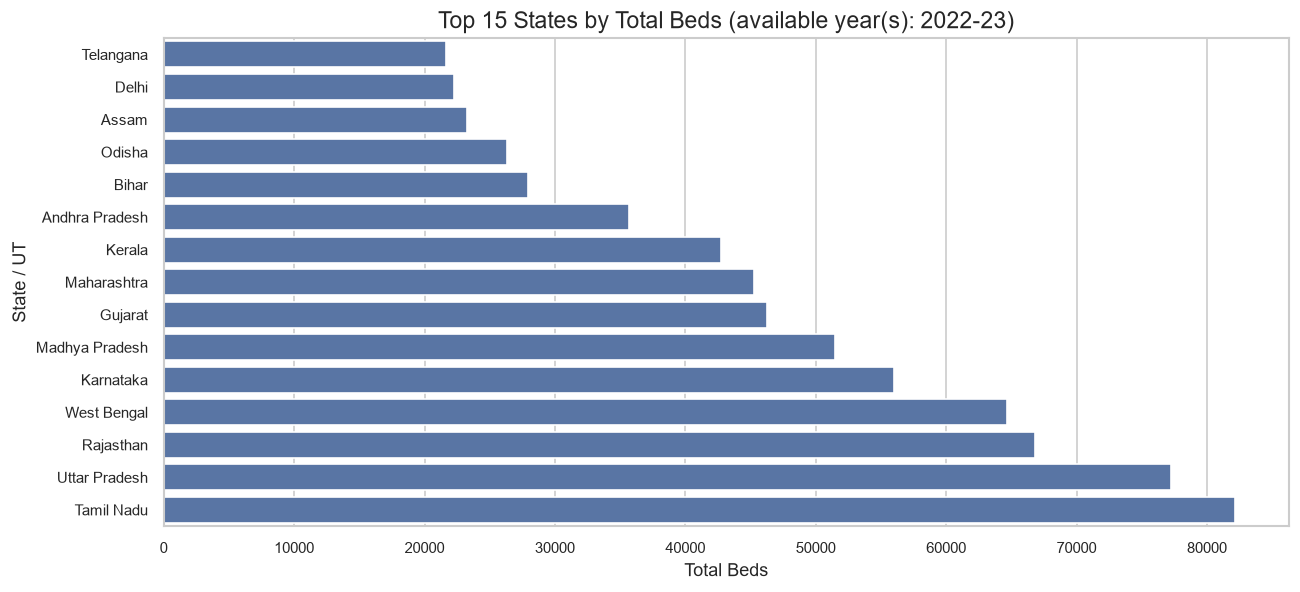

In [5]:
plot_infrastructure_top_states("Total_Beds", "Total Beds")

### Observation

Among the 15 displayed states, Tamil Nadu has the highest reported `Total_Beds`, followed by Uttar Pradesh and Rajasthan. These values are available only for 2022–23 here, so this ranking does not show a trend.

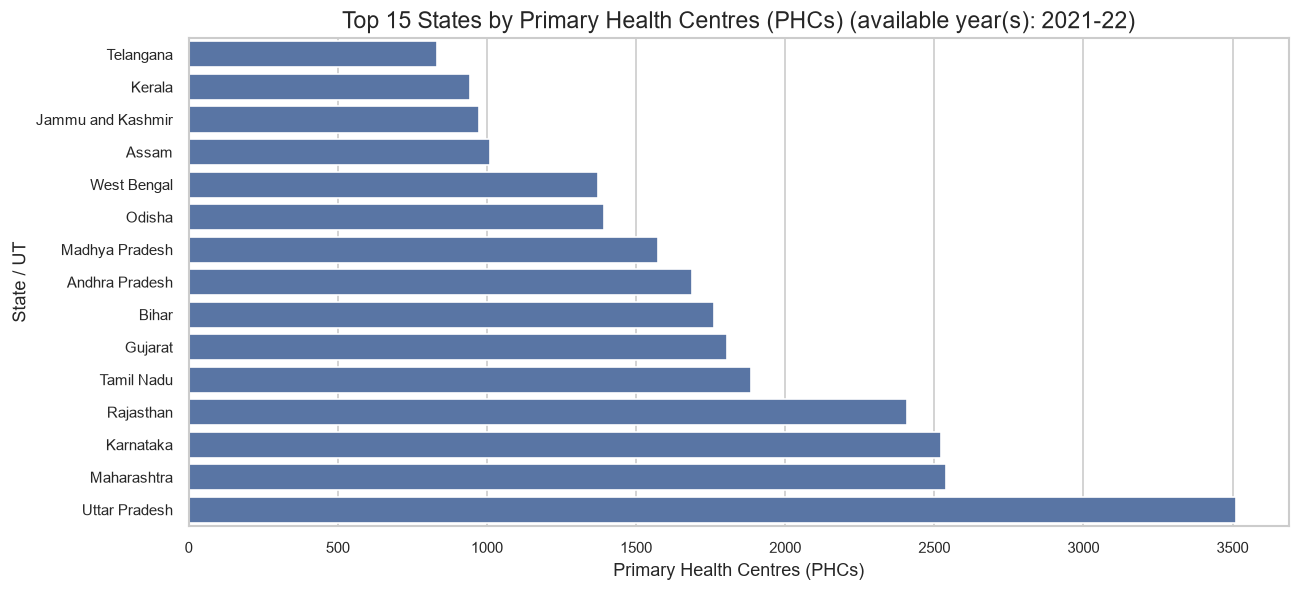

In [6]:
plot_infrastructure_top_states("PHCs", "Primary Health Centres (PHCs)")

### Observation

Uttar Pradesh has the highest reported PHC count among the displayed states for 2021–22. The plot is a ranking for that available year, not a year-over-year comparison.

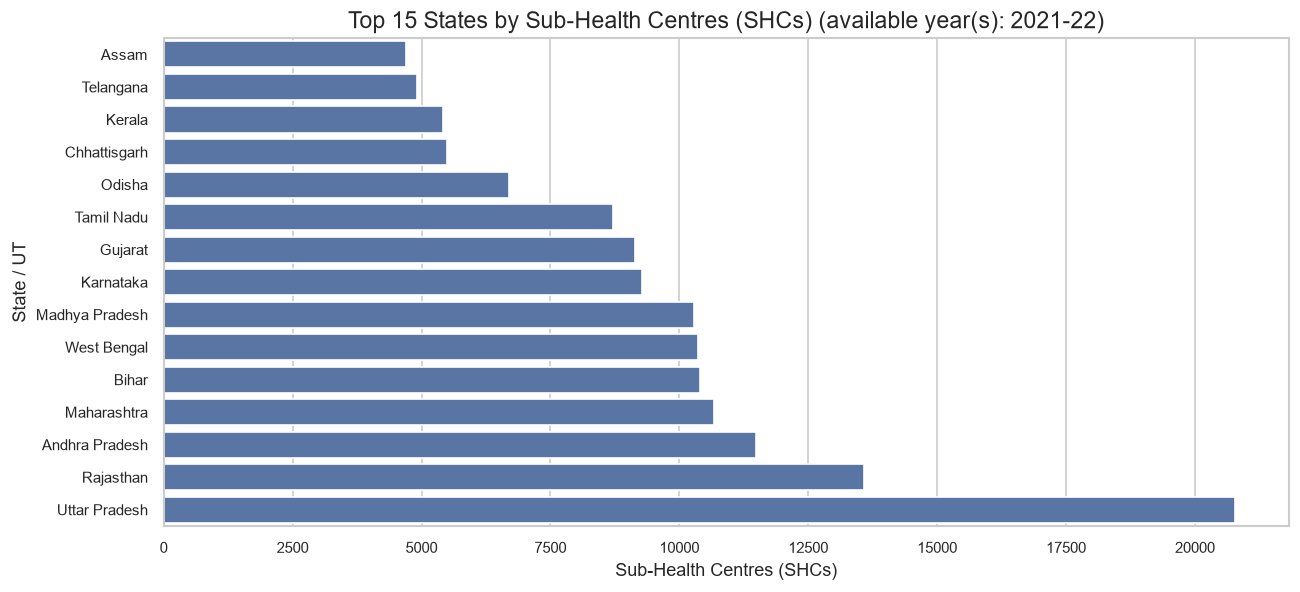

In [7]:
plot_infrastructure_top_states("SHCs", "Sub-Health Centres (SHCs)")

### Observation

Uttar Pradesh has the highest reported SHC count among the displayed states for 2021–22, followed by Rajasthan. The figure reflects the recorded values only.

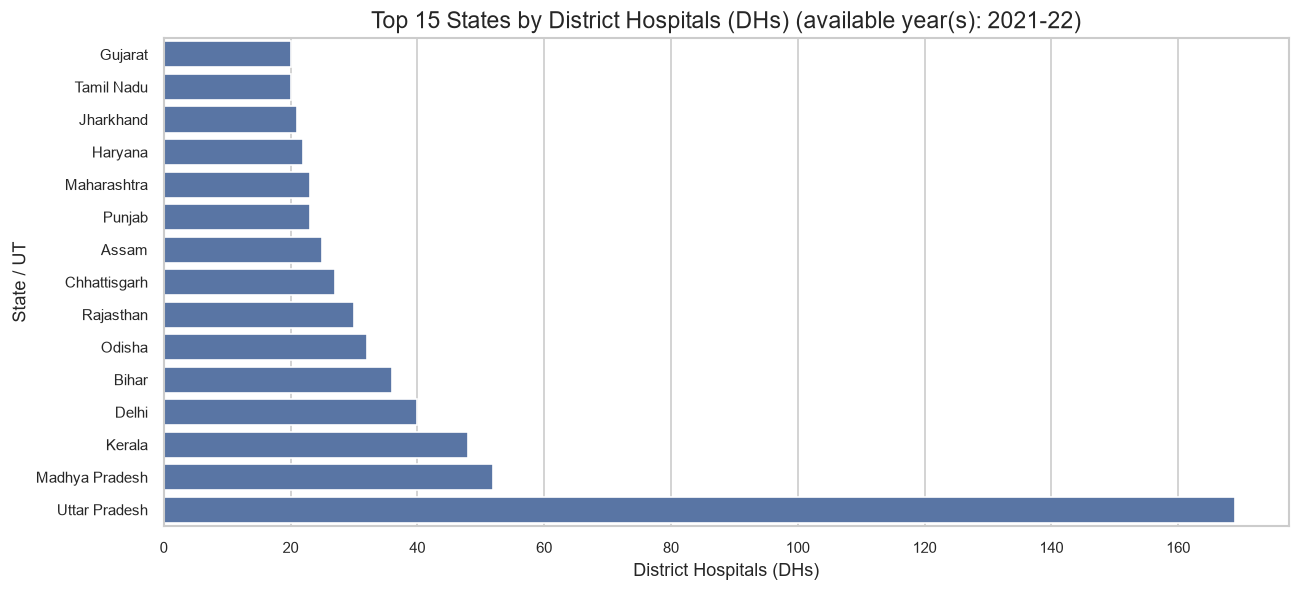

In [8]:
plot_infrastructure_top_states("District_Hospitals", "District Hospitals (DHs)")

### Observation

Uttar Pradesh has the highest reported district-hospital count among the displayed states for 2021–22. The chart shows the values in the source and does not explain differences between states.

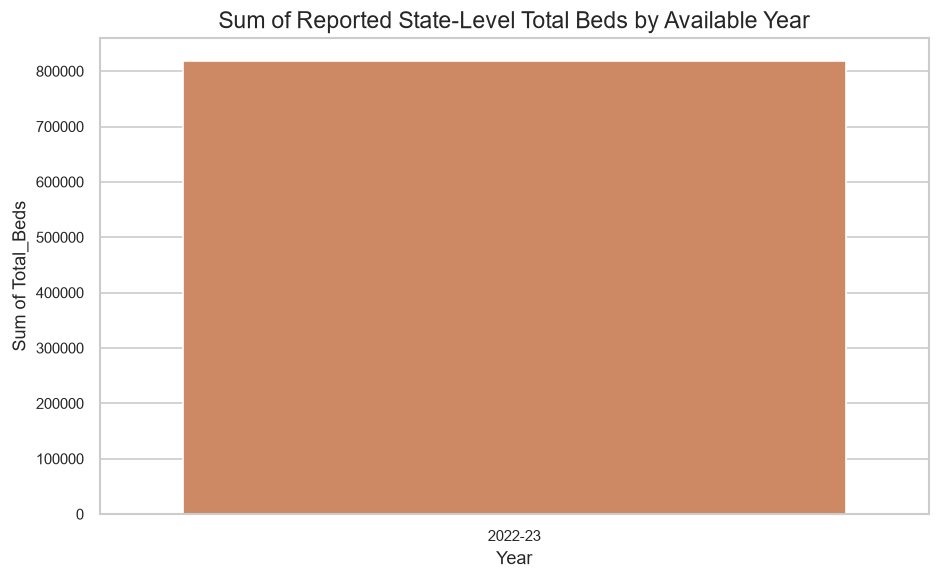

,Year,Total_Beds
0,2022-23,818661.0


In [9]:
plot_total_beds_by_year()

### Observation

Only 2022–23 has non-missing `Total_Beds` values, summing to 818,661 across the state-level rows plotted. With only one available year, this is not a year-over-year comparison.

## Section 4 — Budget EDA

Summarize coverage, numeric distributions, and year/state aggregates. Treat `Expenditure_to_Release_Pct` as a descriptive spending-to-release ratio only; the source does not establish it as official government utilization.

In [10]:
budget = raw_datasets["Budget"].copy()
budget_numeric = budget.select_dtypes(include="number")
print(f"Dataset shape: {budget.shape}")
print("Available years:", sorted(budget["Year"].dropna().astype(str).unique()))
print("Number of states:", budget["State"].nunique(dropna=True))
budget_missing = budget.isna().sum().rename("missing_count").to_frame()
budget_missing["missing_percent"] = budget.isna().mean().mul(100).round(2)
print("Missing values by column:")
display(budget_missing)
print("Descriptive statistics for numeric columns:")
display(budget_numeric.describe().T)

year_summary = (
    budget.groupby("Year", as_index=False)
    .agg(
        State_Rows=("State", "size"),
        Central_Release_Total=("Central_Release", "sum"),
        Expenditure_Total=("Expenditure", "sum"),
        Mean_State_Spending_to_Release_Ratio_Pct=(
            "Expenditure_to_Release_Pct", "mean"
        ),
    )
    .sort_values("Year")
)
year_summary["Aggregate_Spending_to_Release_Ratio_Pct"] = (
    year_summary["Expenditure_Total"]
    .div(year_summary["Central_Release_Total"])
    .mul(100)
)
state_summary = (
    budget.groupby("State", as_index=False)
    .agg(
        Years_Represented=("Year", "nunique"),
        Central_Release_Total=("Central_Release", "sum"),
        Expenditure_Total=("Expenditure", "sum"),
        Mean_Spending_to_Release_Ratio_Pct=(
            "Expenditure_to_Release_Pct", "mean"
        ),
    )
    .sort_values("Expenditure_Total", ascending=False)
)
print("Year-wise summary:")
display(year_summary.round(2))
print("State-wise summary, sorted by total expenditure:")
display(state_summary.round(2))

Dataset shape: (108, 5)
Available years: ['2021-22', '2022-23', '2023-24']
Number of states: 36
Missing values by column:


,missing_count,missing_percent
State,0,0.0
Year,0,0.0
Central_Release,0,0.0
Expenditure,0,0.0
Expenditure_to_Release_Pct,0,0.0


Descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
Central_Release,108.0,851.284537,975.573216,3.790000,94.667500,538.740000,1265.980000,5133.590000
Expenditure,108.0,1528.466389,1783.062904,7.100000,153.857500,917.990000,2324.485000,9044.220000
Expenditure_to_Release_Pct,108.0,183.089025,144.637512,70.832239,116.401819,162.536195,197.750572,1312.941305


Year-wise summary:


,Year,State_Rows,Central_Release_Total,Expenditure_Total,Mean_State_Spending_to_Release_Ratio_Pct,Aggregate_Spending_to_Release_Ratio_Pct
0,2021-22,36,28033.62,47107.53,157.77,168.04
1,2022-23,36,30907.67,58226.14,191.88,188.39
2,2023-24,36,32997.44,59740.70,199.61,181.05


State-wise summary, sorted by total expenditure:


,State,Years_Represented,Central_Release_Total,Expenditure_Total,Mean_Spending_to_Release_Ratio_Pct
33,Uttar Pradesh,3,13297.19,24082.71,182.48
20,Maharashtra,3,6686.10,13730.76,209.32
19,Madhya Pradesh,3,7423.44,13283.25,178.40
28,Rajasthan,3,6171.21,11306.85,193.02
4,Bihar,3,5368.28,9634.13,180.19
30,Tamil Nadu,3,5280.21,9188.80,175.87
25,Odisha,3,4449.53,8859.05,206.86
35,West Bengal,3,3797.00,8557.07,243.83
10,Gujarat,3,3721.50,7800.41,205.36
3,Assam,3,6194.82,7128.23,114.99


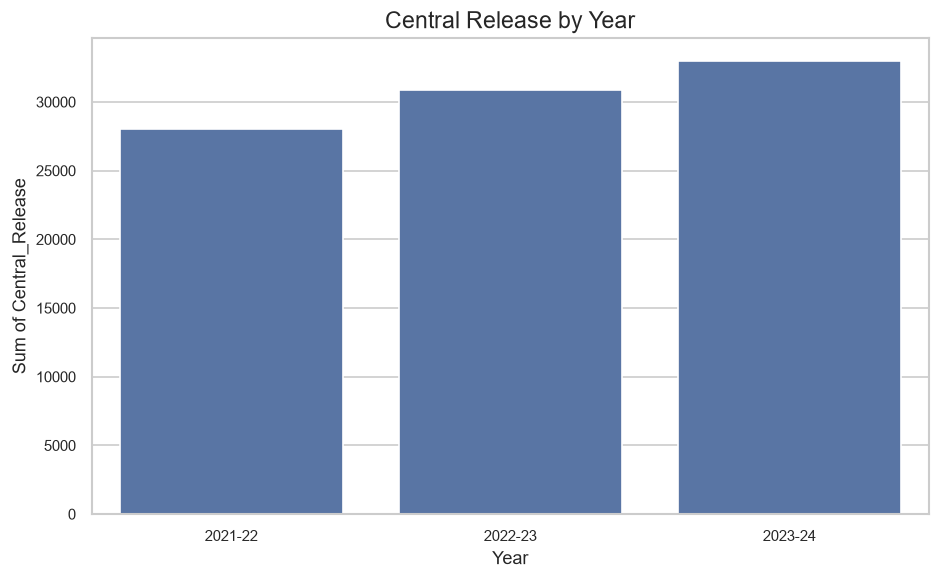

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=year_summary,
    x="Year",
    y="Central_Release_Total",
    color=sns.color_palette("deep")[0],
    ax=ax,
)
ax.set_title("Central Release by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Sum of Central_Release")
plt.tight_layout()
plt.show()

### Observation

Summed Central_Release increases across the three available years: 28,033.62, 30,907.67, and 32,997.44. These are totals across the 36 state rows per year in this dataset.

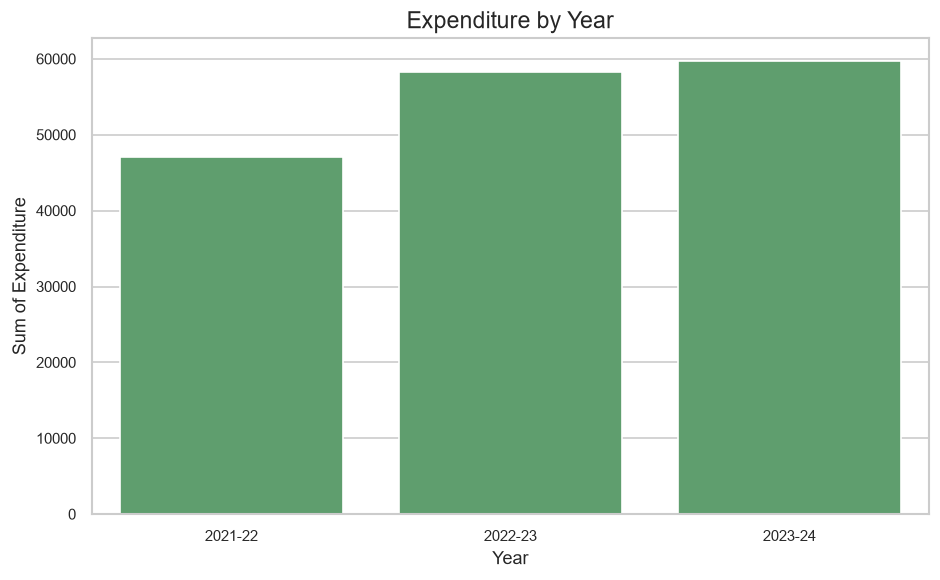

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=year_summary,
    x="Year",
    y="Expenditure_Total",
    color=sns.color_palette("deep")[2],
    ax=ax,
)
ax.set_title("Expenditure by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Sum of Expenditure")
plt.tight_layout()
plt.show()

### Observation

Summed Expenditure rises from 47,107.53 in 2021–22 to 58,226.14 in 2022–23 and 59,740.70 in 2023–24. Its increase is smaller in the last interval than in the preceding one.

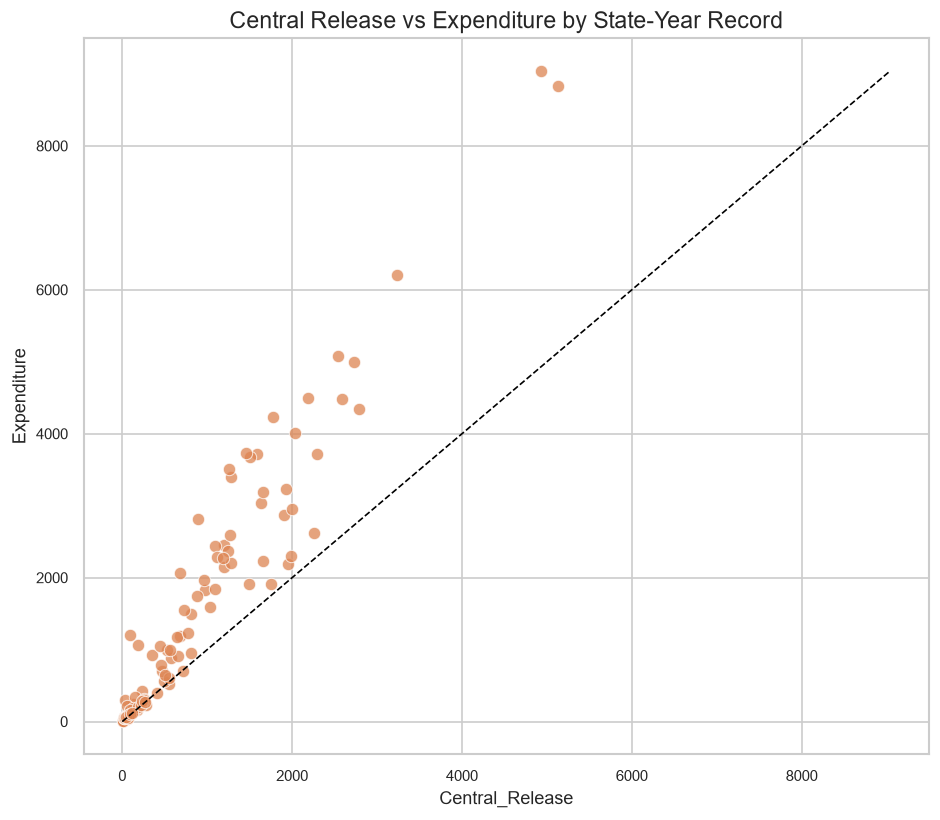

Records relative to the equality reference line: 94 above, 14 below, 0 equal.


In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    data=budget,
    x="Central_Release",
    y="Expenditure",
    color=sns.color_palette("deep")[1],
    alpha=0.75,
    s=55,
    ax=ax,
)
axis_max = max(budget["Central_Release"].max(), budget["Expenditure"].max())
ax.plot([0, axis_max], [0, axis_max], color="black", linestyle="--", linewidth=1)
ax.set_title("Central Release vs Expenditure by State-Year Record")
ax.set_xlabel("Central_Release")
ax.set_ylabel("Expenditure")
plt.tight_layout()
plt.show()
above_reference = int((budget["Expenditure"] > budget["Central_Release"]).sum())
below_reference = int((budget["Expenditure"] < budget["Central_Release"]).sum())
equal_reference = int((budget["Expenditure"] == budget["Central_Release"]).sum())
print(
    "Records relative to the equality reference line: "
    f"{above_reference} above, {below_reference} below, "
    f"{equal_reference} equal."
)

### Observation

Ninety-four of the 108 state-year records lie above the expenditure-equals-release reference line, and 14 lie below it. Points are concentrated at lower release amounts with several larger observations; the plot does not explain these differences.

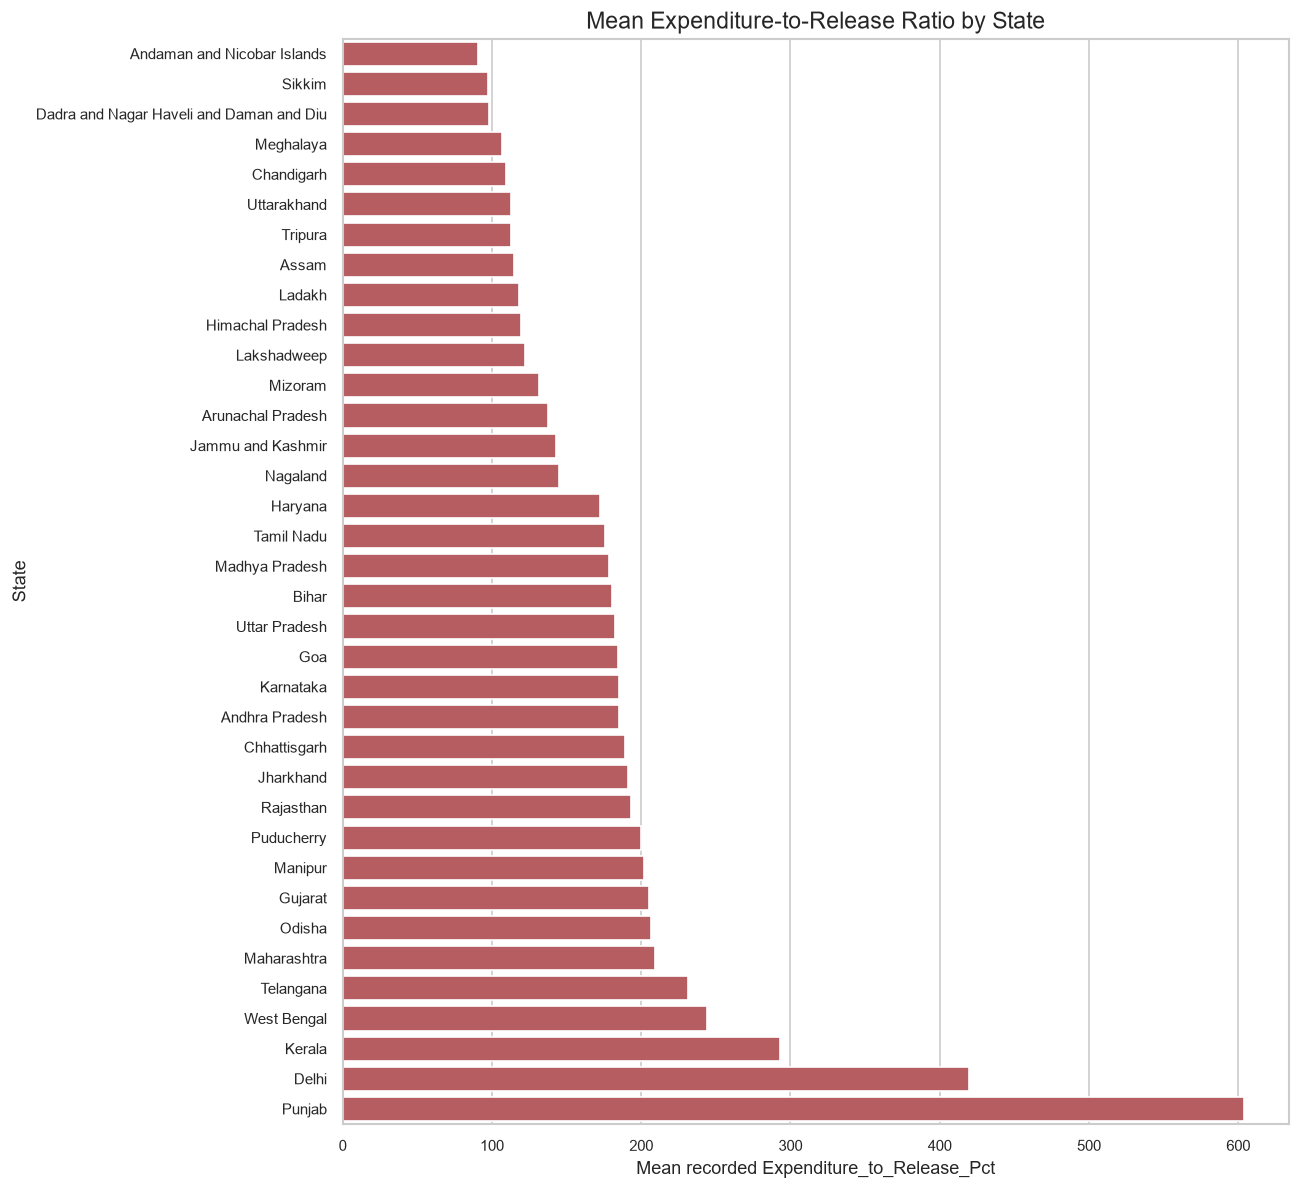

In [14]:
ratio_plot_data = state_summary.sort_values(
    "Mean_Spending_to_Release_Ratio_Pct", ascending=True
)
fig, ax = plt.subplots(figsize=(11, max(8, 0.28 * len(ratio_plot_data))))
sns.barplot(
    data=ratio_plot_data,
    x="Mean_Spending_to_Release_Ratio_Pct",
    y="State",
    order=ratio_plot_data["State"],
    color=sns.color_palette("deep")[3],
    ax=ax,
)
ax.set_title("Mean Expenditure-to-Release Ratio by State")
ax.set_xlabel("Mean recorded Expenditure_to_Release_Pct")
ax.set_ylabel("State")
plt.tight_layout()
plt.show()

### Observation

Punjab has the highest mean recorded spending-to-release ratio across the supplied years (603.66%), while Andaman and Nicobar Islands has the lowest (90.81%). These are descriptive ratios from the recorded column, not official utilization measures.

## Section 5 — HMIS EDA

HMIS has more than 100,000 rows, so use compact tables and bounded charts. Inspect missingness, categories, states, numeric values, and reporting-period contents. Do not infer dates or create a disease time-series plot.

In [15]:
hmis = raw_datasets["HMIS"].copy()
print(f"Dataset shape: {hmis.shape}")
print(f"Columns: {list(hmis.columns)}")
hmis_missing = hmis.isna().sum().rename("missing_count").to_frame()
hmis_missing["missing_percent"] = hmis.isna().mean().mul(100).round(2)
print("Missing-value counts and percentages:")
display(hmis_missing)

hmis_category_counts = hmis["Observation_Category"].value_counts(dropna=False)
print("Observation_Category distribution:")
display(hmis_category_counts.rename("row_count").to_frame())
hmis_state_counts = hmis["State"].value_counts().head(15)
print(f"Number of states: {hmis['State'].nunique(dropna=True)}")
print("Most frequent State labels (top 15):")
display(hmis_state_counts.rename("row_count").to_frame())

print("Value_Numeric descriptive statistics:")
display(hmis["Value_Numeric"].describe().to_frame().T)
value_numeric_missing_percent = hmis["Value_Numeric"].isna().mean() * 100
print(
    f"Value_Numeric missing: {hmis['Value_Numeric'].isna().sum():,} rows "
    f"({value_numeric_missing_percent:.2f}%)."
)

reporting_period_values = hmis["Reporting_Period"].dropna().unique().tolist()
reporting_period_dates = pd.to_datetime(
    hmis["Reporting_Period"], errors="coerce", format="mixed"
)
reporting_period_date_rows = int(reporting_period_dates.notna().sum())
reporting_period_year_rows = int(
    hmis["Reporting_Period"]
    .astype("string")
    .str.contains(r"\b(?:19|20)\d{2}\b", regex=True, na=False)
    .sum()
)
print(f"Reporting_Period unique values: {reporting_period_values}")
print(
    f"Parseable date rows: {reporting_period_date_rows}; "
    f"rows containing a four-digit year: {reporting_period_year_rows}."
)
if reporting_period_date_rows == 0 and reporting_period_year_rows == 0:
    print(
        "The current HMIS dataset does not contain a reliable inferred "
        "year/month/date, therefore disease time-series forecasting cannot "
        "be justified from this dataset alone."
    )

Dataset shape: (101840, 9)
Columns: ['Indicator', 'S.No.', 'Parameters', 'Type', 'State', 'Observation_Category', 'Value', 'Value_Numeric', 'Reporting_Period']
Missing-value counts and percentages:


,missing_count,missing_percent
Indicator,0,0.00
S.No.,0,0.00
Parameters,0,0.00
Type,0,0.00
State,0,0.00
Observation_Category,0,0.00
Value,44862,44.05
Value_Numeric,44862,44.05
Reporting_Period,0,0.00


Observation_Category distribution:


,row_count
Observation_Category,
Total [(A+B) or (C+D)],20368
Public [A],20368
Private [B],20368
Urban [C],20368
Rural [D],20368


Number of states: 37
Most frequent State labels (top 15):


,row_count
State,
Dadra and Nagar Haveli and Daman and Diu,5360
Andaman and Nicobar Islands,2680
Andhra Pradesh,2680
Arunachal Pradesh,2680
Assam,2680
Bihar,2680
Chandigarh,2680
Chhattisgarh,2680
Delhi,2680


Value_Numeric descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Value_Numeric,56978.0,98261.324652,1.635101e+06,-429091.0,0.0,119.0,3079.75,108208275.0


Value_Numeric missing: 44,862 rows (44.05%).
Reporting_Period unique values: ['Source snapshot (date not inferred)']
Parseable date rows: 0; rows containing a four-digit year: 0.
The current HMIS dataset does not contain a reliable inferred year/month/date, therefore disease time-series forecasting cannot be justified from this dataset alone.


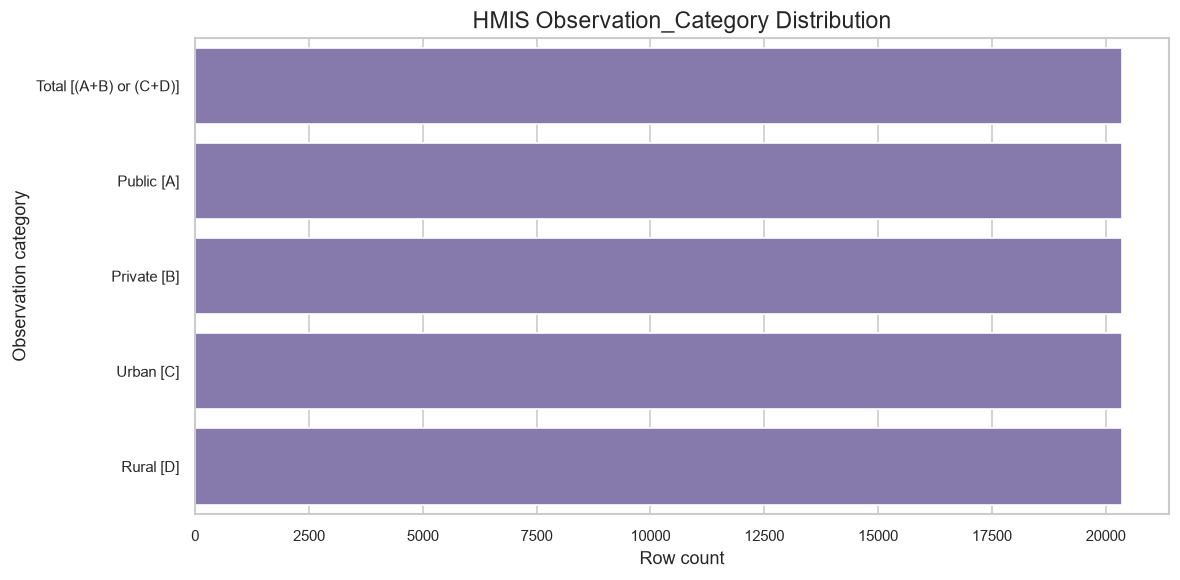

In [16]:
category_plot_data = hmis_category_counts.sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=category_plot_data.values,
    y=category_plot_data.index.astype(str),
    color=sns.color_palette("deep")[4],
    ax=ax,
)
ax.set_title("HMIS Observation_Category Distribution")
ax.set_xlabel("Row count")
ax.set_ylabel("Observation category")
plt.tight_layout()
plt.show()

### Observation

All five `Observation_Category` values have 20,368 rows each. This describes the frequency distribution in the file and does not explain how the categories were collected.

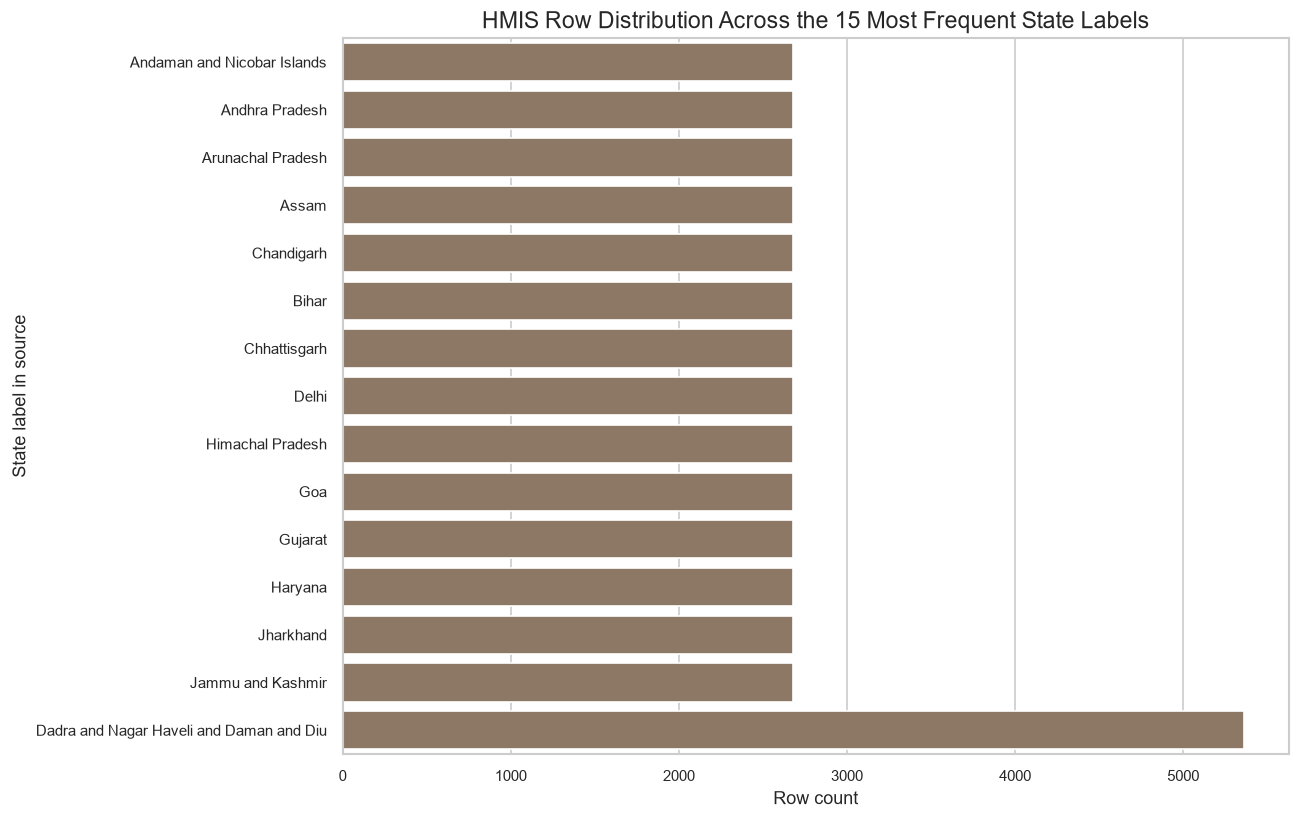

In [17]:
hmis_state_plot_data = hmis_state_counts.sort_values(ascending=True)
fig, ax = plt.subplots(
    figsize=(11, max(7, 0.34 * len(hmis_state_plot_data)))
)
sns.barplot(
    x=hmis_state_plot_data.values,
    y=hmis_state_plot_data.index,
    color=sns.color_palette("deep")[5],
    ax=ax,
)
ax.set_title("HMIS Row Distribution Across the 15 Most Frequent State Labels")
ax.set_xlabel("Row count")
ax.set_ylabel("State label in source")
plt.tight_layout()
plt.show()

### Observation

The top 15 source state labels each have 2,680 rows except `Dadra and Nagar Haveli and Daman and Diu`, which has 5,360. These are frequency counts for the exact labels in the file.

## Section 6 — Correlation and Relationship Analysis

Correlations use numeric measurement columns only. State names, years, indicator labels, and other categories are not encoded as numeric values. HMIS correlations are limited to its measured-value fields.

Infrastructure numeric pairwise observation counts:


,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
SHCs,36,36,36,0,0,0,0,0,0
PHCs,36,36,36,0,0,0,0,0,0
District_Hospitals,36,36,36,0,0,0,0,0,0
PHC_Beds,0,0,0,36,35,28,36,32,36
CHC_Beds,0,0,0,35,35,27,35,31,35
SDH_Beds,0,0,0,28,27,28,28,27,28
District_Hospital_Beds,0,0,0,36,35,28,36,32,36
Medical_College_Beds,0,0,0,32,31,27,32,32,32
Total_Beds,0,0,0,36,35,28,36,32,36


Infrastructure correlations (pairs with fewer than 3 rows hidden):


,SHCs,PHCs,District_Hospitals,PHC_Beds,CHC_Beds,SDH_Beds,District_Hospital_Beds,Medical_College_Beds,Total_Beds
SHCs,1.000000,0.955843,0.711778,NaN,NaN,NaN,NaN,NaN,NaN
PHCs,0.955843,1.000000,0.664368,NaN,NaN,NaN,NaN,NaN,NaN
District_Hospitals,0.711778,0.664368,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
PHC_Beds,NaN,NaN,NaN,1.000000,0.852799,0.668847,0.565557,0.737995,0.867848
CHC_Beds,NaN,NaN,NaN,0.852799,1.000000,0.503174,0.779865,0.743647,0.894334
SDH_Beds,NaN,NaN,NaN,0.668847,0.503174,1.000000,0.510079,0.769358,0.841486
District_Hospital_Beds,NaN,NaN,NaN,0.565557,0.779865,0.510079,1.000000,0.466653,0.765071
Medical_College_Beds,NaN,NaN,NaN,0.737995,0.743647,0.769358,0.466653,1.000000,0.896112
Total_Beds,NaN,NaN,NaN,0.867848,0.894334,0.841486,0.765071,0.896112,1.000000


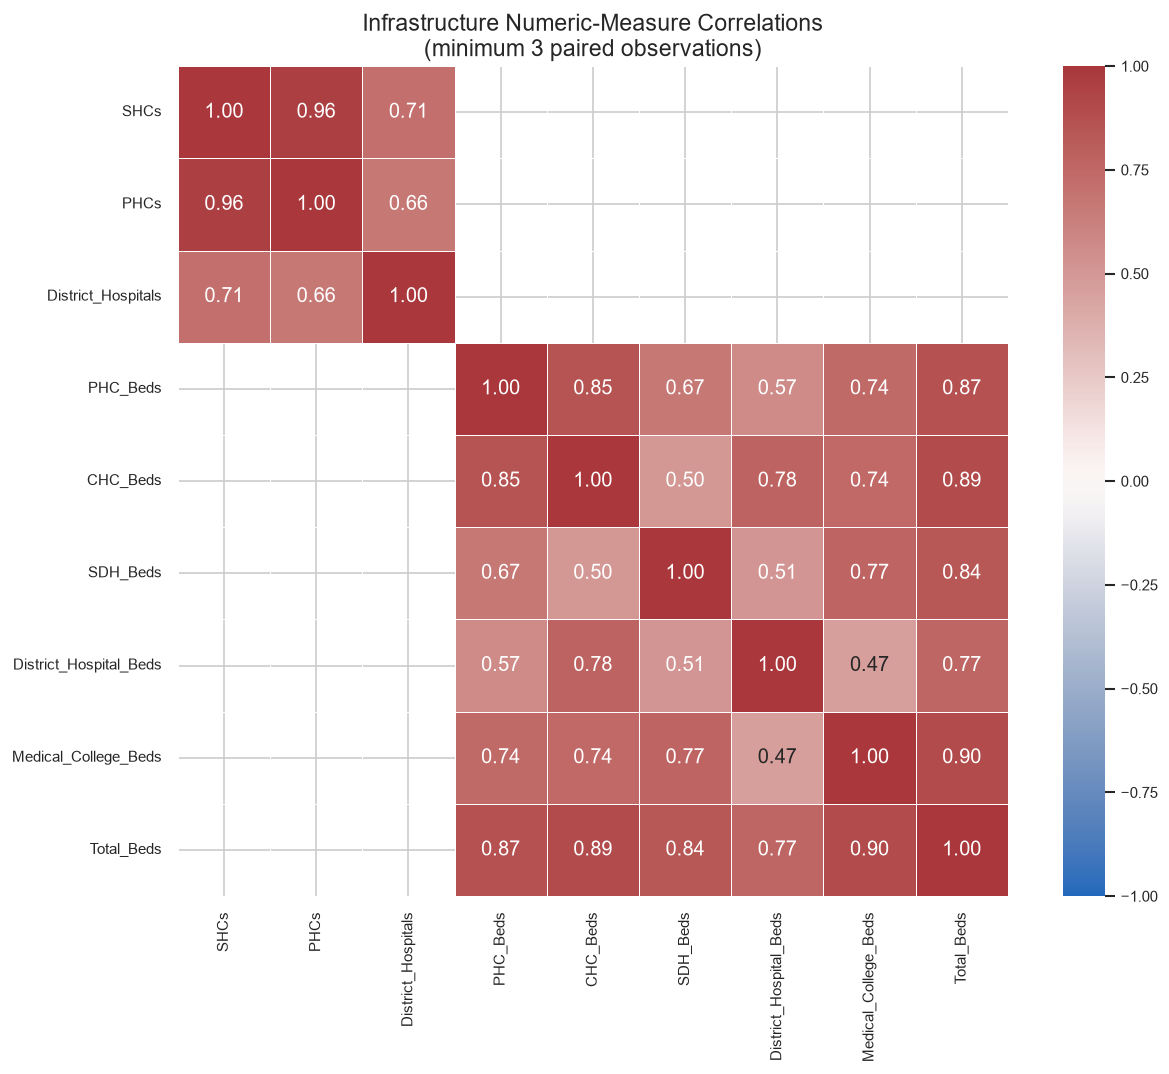

In [18]:
infrastructure_numeric_for_corr = infrastructure_state_rows.select_dtypes(
    include="number"
)
infrastructure_pair_counts = infrastructure_numeric_for_corr.notna().astype(int).T.dot(
    infrastructure_numeric_for_corr.notna().astype(int)
)
infrastructure_correlation = infrastructure_numeric_for_corr.corr(min_periods=3)
insufficient_pairs = infrastructure_pair_counts < 3
print("Infrastructure numeric pairwise observation counts:")
display(infrastructure_pair_counts)
print("Infrastructure correlations (pairs with fewer than 3 rows hidden):")
display(infrastructure_correlation)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    infrastructure_correlation,
    mask=insufficient_pairs,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Infrastructure Numeric-Measure Correlations\n(minimum 3 paired observations)")
plt.tight_layout()
plt.show()

### Observation

Facility-count measures have 36 paired observations with one another, while bed measures overlap within the 2022–23 records. Facility counts and bed columns have zero jointly observed rows in this file, so their cross-group correlations are left blank.

Budget numeric correlation matrix:


,Central_Release,Expenditure,Expenditure_to_Release_Pct
Central_Release,1.000000,0.964649,-0.021561
Expenditure,0.964649,1.000000,0.102576
Expenditure_to_Release_Pct,-0.021561,0.102576,1.000000


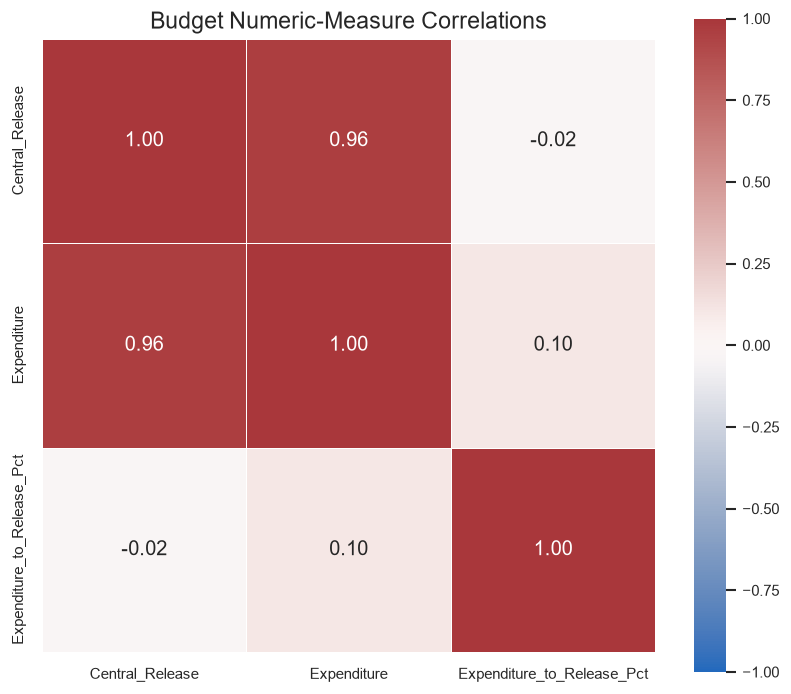

In [19]:
budget_numeric_for_corr = budget.select_dtypes(include="number")
budget_correlation = budget_numeric_for_corr.corr(min_periods=3)
print("Budget numeric correlation matrix:")
display(budget_correlation)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    budget_correlation,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Budget Numeric-Measure Correlations")
plt.tight_layout()
plt.show()

### Observation

Central_Release and Expenditure have a positive numeric correlation of about 0.96 in this sample. The recorded ratio has weak pairwise correlations here; these values are descriptive and do not establish causation or official accounting meaning.

Rows with both HMIS value fields populated: 56,978
Paired rows where Value equals Value_Numeric: 56,978


,Value,Value_Numeric
Value,1.0,1.0
Value_Numeric,1.0,1.0


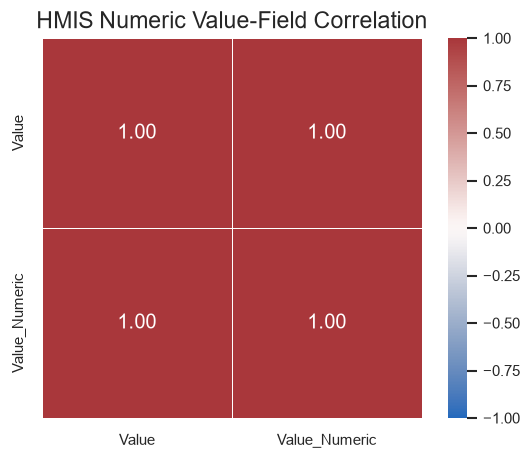

In [20]:
hmis_numeric_for_corr = hmis[["Value", "Value_Numeric"]].select_dtypes(
    include="number"
)
if hmis_numeric_for_corr.shape[1] >= 2:
    hmis_value_pairs = hmis_numeric_for_corr.dropna()
    values_match = np.isclose(
        hmis_value_pairs["Value"],
        hmis_value_pairs["Value_Numeric"],
        rtol=1e-9,
        atol=1e-9,
    )
    hmis_numeric_correlation = hmis_numeric_for_corr.corr(min_periods=3)
    print(f"Rows with both HMIS value fields populated: {len(hmis_value_pairs):,}")
    print(f"Paired rows where Value equals Value_Numeric: {int(values_match.sum()):,}")
    display(hmis_numeric_correlation)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        hmis_numeric_correlation,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title("HMIS Numeric Value-Field Correlation")
    plt.tight_layout()
    plt.show()
else:
    print("No pair of meaningful numeric HMIS value fields is available to correlate.")

### Observation

`Value` and `Value_Numeric` match in all 56,978 rows where both are populated, which explains the heatmap's correlation of 1.00. This is a duplicate numeric representation, not an independent association; no categorical fields were encoded.

## Section 7 — EDA Findings and ML Readiness

### Infrastructure
- **Important patterns:** The file contains 36 state labels plus aggregate rows across 2021–22 and 2022–23. The facility-count measures are populated for 2021–22, while `Total_Beds` is populated for 2022–23. Among the plotted state rows, Tamil Nadu, Uttar Pradesh, and Rajasthan have the largest reported total bed counts.
- **Useful ML variables:** `State`, `Year`, facility counts, and bed measures may be useful after consistent time coverage and target definitions are established.
- **Missing-data issues:** 346 of 814 cells are missing (42.51%). Missingness differs by measure and year; no values were filled.
- **Limitations:** Most measures have only one observed year. Facility counts and bed measures have no overlapping observations, so their cross-group relationships cannot be estimated from this file.

### Budget
- **Important patterns:** Summed Central Release and Expenditure rise across 2021–22, 2022–23, and 2023–24. Their numeric correlation is about 0.96 in this sample.
- **Useful ML variables:** `State`, `Year`, `Central_Release`, and prior-period `Expenditure` could be considered for future feature engineering.
- **Target candidate:** `Expenditure` is a candidate target for a clearly defined future budget prediction task.
- **Limitations:** The file has only three annual periods. That is limited history for forecasting and time-based model evaluation. `Expenditure_to_Release_Pct` is described only as a spending-to-release ratio, not official utilization.

### HMIS / Disease
- **Important patterns:** The five observation categories each contain 20,368 rows. `Value_Numeric` is missing in 44,862 rows (44.05%); where both numeric value fields are present, `Value` and `Value_Numeric` match.
- **Useful variables:** `Indicator`, `S.No.`, `Parameters`, `Type`, `State`, `Observation_Category`, and `Value_Numeric` may support a defined cross-sectional analysis after an observation key and missingness approach are established.
- **Time-series suitability:** `Reporting_Period` contains only `Source snapshot (date not inferred)`, with no parseable dates or four-digit years. The current HMIS dataset does not contain a reliable inferred year/month/date, therefore disease time-series forecasting cannot be justified from this dataset alone.
- **Additional data required:** Documented historical HMIS observations with explicit reporting year/month/date and stable identifiers for indicator, location, category, and period.

### Overall ML Readiness

| Dataset | Current Status | Potential ML Target | Main Limitation |
|---|---|---|---|
| Infrastructure | Review required | Future facility or bed counts, after coverage is expanded | High metric-specific missingness and one observed year per measure |
| Budget | Ready for feature engineering | Expenditure | Only three annual periods; forecasting needs more history and time-based validation |
| HMIS / Disease | Needs additional data | `Value_Numeric` for a defined indicator and population | No usable date, substantial missing values, and no unique observation key established |

This notebook is descriptive EDA only. It does not merge datasets, remove rows, modify the CSVs, infer dates, or train models.